In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows, medfilt, savgol_filter
import pandas as pd
import datetime
from time import sleep
from glob import glob
import matplotlib.gridspec as gridspec

import pyonb
from PyQt5.QtCore import QVariant, QByteArray, QDataStream, QIODevice
import encosid

SIGNAL_DT_MS = 1. # 1ms

In [18]:
DATA_DIR = "tenso/"

def save(path, data):
    np.savez(DATA_DIR + path, **data)

def load(path):
    return np.load(DATA_DIR + path)

## Идентификация $K_t$

1. Устанавливаем двигатель на тензометрический стенд.
3. Фиксируем вал при помощи элетротормоза
2. В квазистатическом режиме снимаем зависимость момента $\tau(I)$

In [12]:
brake = None
onb = None
encosid.get_id("can0")
brake_id = encosid.get_id("can0")
brake = encosid.SignalGenerator("can0", brake_id)
onb = pyonb.Client()

Found id #3
Found id #3


In [13]:
def tenso_experiment(freq_start, freq_end, duration, amplitude, brake_kp):
  # Fetch devices
  onb.fetch_device("drive")
  onb.fetch_device("Analyzer")
  onb.fetch_device("SigGen")

  DURATION   = duration   # s
  FREQ_START = freq_start # Hz
  FREQ_END   = freq_end   # Hz
  AMPLITUDE  = amplitude  # Nm
  BRAKE_KP   = brake_kp

  onb.set_param_bool("drive", "enable", True)

  onb.set_param_float("Analyzer", "freqStart", FREQ_START)
  onb.set_param_float("Analyzer", "freqEnd",   FREQ_END)
  onb.set_param_float("Analyzer", "duration",  DURATION)

  onb.invoke_str("Analyzer", "set input", "torque")
  onb.set_param_float("Analyzer", "targetAmplitude", AMPLITUDE)

  # Measuring process
  onb.set_ag_request("drive", 5, ["speed", "tensoFiltered", "torque", "targetTorque"])

  brake.brake(BRAKE_KP, 0)
  onb.invoke_str("Analyzer", "start/stop")
  sleep(DURATION)
  brake.release()

  onb.set_ag_request("drive", 0, []) # disable
  samples = onb.get_samples()

  print(f"Number of samples: {len(samples)}")

  def decode_samples(samples):
    ret = []

    for sample in samples:
      b = bytearray(map(ord, sample))

      arr = QByteArray(b)
      ds = QDataStream(arr, QIODevice.ReadOnly)

      v = QVariant()
      ds >> v

      ret.append(v.value())
    
    return ret

  data = decode_samples(samples)

  def extract_key(data, key):
    d = []
    for sample in data:
      if key in sample:
        d.append(sample[key])
    
    return np.array(d)

  current = extract_key(data, 'torque')
  tenso   = extract_key(data, 'tensoFiltered')
  target_torque = extract_key(data, 'targetTorque')

  return target_torque, tenso, current



In [19]:
target_torque, tenso, current = tenso_experiment(
    freq_start=(1 / 30),
    freq_end=(1 / 30),
    duration=30,
    amplitude=20,
    brake_kp=20
)

out = {'tenso_torque': tenso,
        'current': current,
        'target_torque': target_torque}

save("kt.npz", out)

Number of samples: 7884


NpzFile 'tenso/kt.npz' with keys: tenso_torque, current, target_torque
[1.87175896 0.54439092] [ 1.89272018 -0.99201952]
1.8822395710707052 0.768205219524212


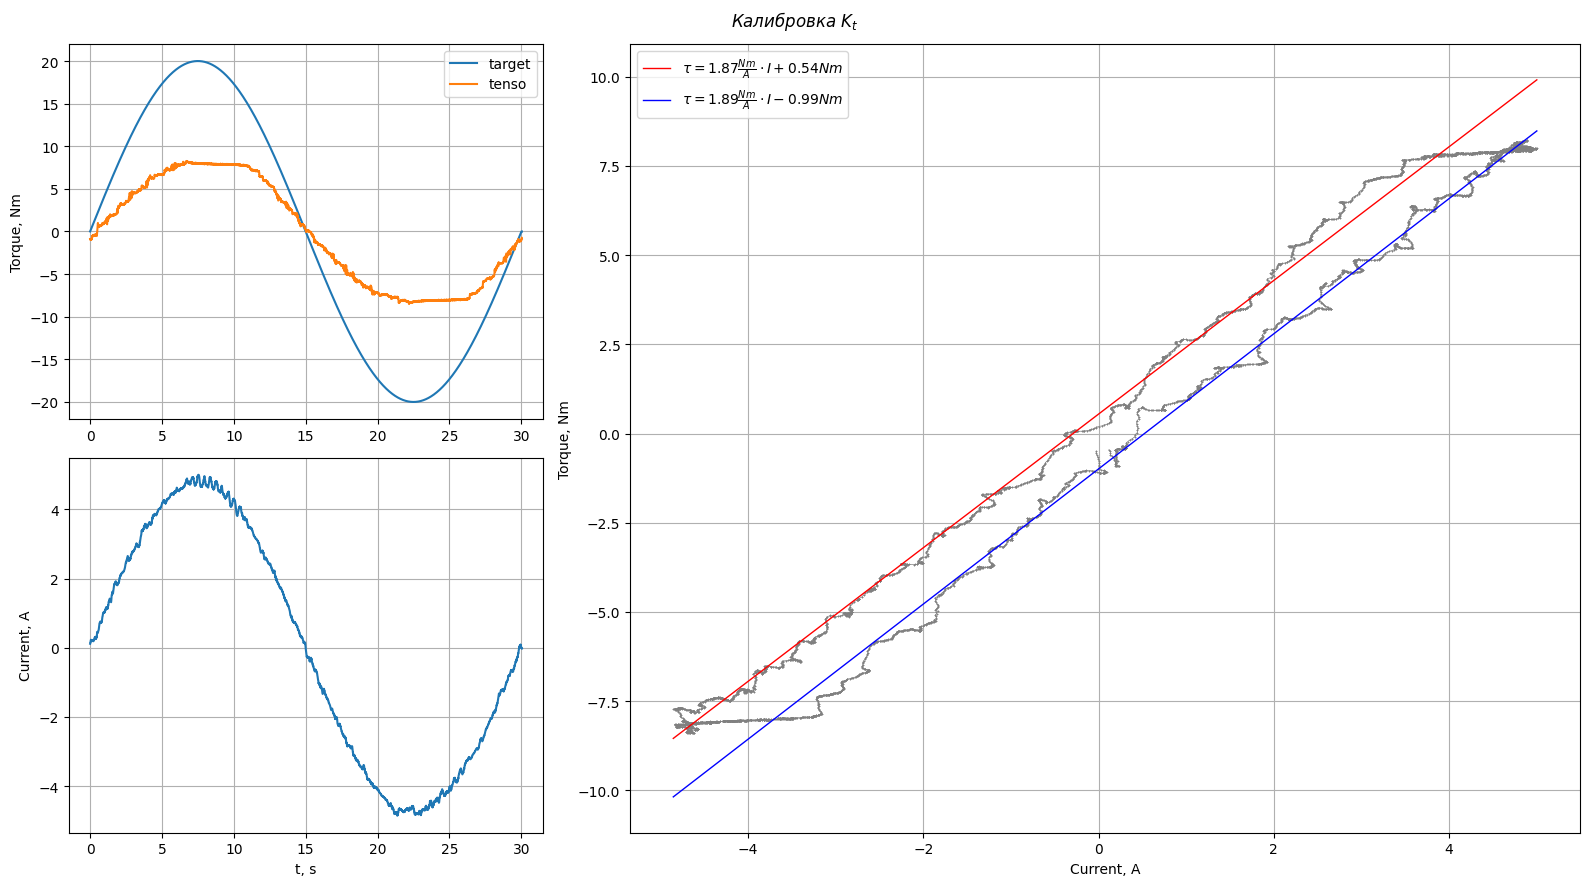

In [20]:
out = load("kt.npz")
print(out)

target_torque = out["target_torque"]
current = out["current"]
tenso_torque = out["tenso_torque"]

T = np.arange(0, len(current), 1) * SIGNAL_DT_MS * 5 * 1e-3

torque = tenso_torque
wlen = 20
current = np.convolve(current, np.ones(wlen) / wlen, mode='same')
torque = np.convolve(torque, np.ones(wlen) / wlen, mode='same')

x = [np.min(current), np.max(current)]

p = np.polyfit(current, torque, 1)

mask = torque > np.polyval(p, current)
eps = .00
ifront = np.where((torque > np.polyval(p, current) + eps) * (np.abs(current) < 6))
iback = np.where((torque < np.polyval(p, current) - eps) * (np.abs(current) < 6))

pf = np.polyfit(current[ifront], torque[ifront], 1)
pb = np.polyfit(current[iback], torque[iback], 1)

fig=plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[:, 1])

ax1.plot(T, target_torque, label="target")
ax2.plot(T, current, label="current")
ax1.plot(T, tenso_torque, label="tenso")
ax2.set_ylabel("Current, A")
ax1.legend()
ax1.set_ylabel("Torque, Nm")
ax1.grid()
ax2.grid()
ax2.set_xlabel("t, s")

ax3.plot(current, torque, marker='x', color='gray', lw=.5, ms=.7)

nma = "\\frac{Nm}{A}"
ax3.plot(x, np.polyval(pf, x), 'r-', lw=1, label=f"$\\tau = {round(pf[0], 2)}{nma}\\cdot I + {round(pf[1], 2)}Nm$")
ax3.plot(x, np.polyval(pb, x), 'b-', lw=1, label=f"$\\tau = {round(pb[0], 2)}{nma}\\cdot I - {round(-pb[1], 2)}Nm$")

ax3.legend()
ax3.grid()
ax3.set_ylabel("Torque, Nm")
ax3.set_xlabel("Current, A")
#ax3.set_title("Drive/Backdrive diagram")

plt.suptitle("$Калибровка ~K_t$")
plt.tight_layout()

print(pf, pb)

KT_REAL = (pf[0] + pb[0]) / 2
COULOMB_FRICTION = (abs(pf[1]) + abs(pb[1])) / 2

print(KT_REAL, COULOMB_FRICTION)

### Проверка корректности измерений момента по току

Проверяем, что $\tau_{meas} = I(\tau_{target}) \cdot K_t \approx \tau_{target}$ вне квазистатического режима. Эта зависимость может нарушаться при некорректной настройке регулятора тока в контуре управления электромотора. Измерения проводились при следующей конфигурации FOC:
$$R   = 156.5~\text{мОм} \\
L   = 28.48~\text{мкГн} \\
\lambda = 3.732~\text{мВб} \\
K_P = 0.05 \\
K_I = 1800.53 \\
G   = 71.80$$

Параметры $R, ~L, \lambda, G$ измеряются путем штатной калибровки электродвигателя. Параметры контроллера $K_P, ~K_I$ были подобраны экспериментально, чтобы удовлетворить указанное выше равенство целевого и измеренного моментов

In [ ]:
target_torque, tenso, current = tenso_experiment(
    freq_start=0.7,
    freq_end=0.7,
    duration=10,
    amplitude=10,
    brake_kp=0
)

out = {'tenso_torque': tenso,
        'current': current,
        'target_torque': target_torque}

save("kt_validation.npz", **out)

Number of samples: 2630


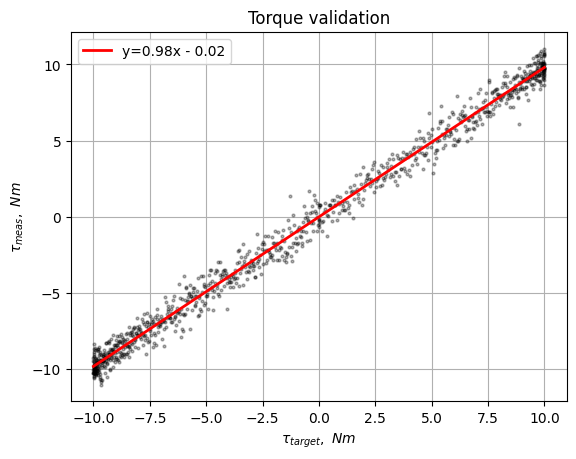

In [5]:
out = load("kt_validation.npz")
lim = 1000
target_torque = out["target_torque"][lim:]
current = out["current"][lim:]
tenso_torque = out["tenso_torque"][lim:]

tq = current * KT_REAL

p = np.polyfit(target_torque, tq, 1)
x = [np.min(target_torque), np.max(target_torque)]


plt.plot(target_torque, tq, 'ko', ms=2, alpha=.3)
plt.plot(x, np.polyval(p, x), 'r-', lw=2, label=f"y={round(p[0], 2)}x - {round(abs(p[1]), 2)}")
plt.ylabel("$\\tau_{meas}, ~Nm$")
plt.xlabel("$\\tau_{target}, ~Nm$")
plt.grid()
plt.legend()
plt.title("Torque validation")
plt.show()

## Идентификация трения

1. Сгенерируем дискретно возрастающий сигнал управления по целевой скорости $\dot{\theta}_{target}$

2. Снимаем зависимость $\tau_{meas}(\dot{\theta}) = K_t \cdot I (\dot{\theta})$, что в установившемся режиме соответствует моменту сил трения

3. Повторяем эксперимент при другом направлении вращения

In [3]:
brake = None
gen = None
gen = encosid.SignalGenerator("can0", 3)

In [6]:
STEPS_PER_S = .125

T = np.arange(0, 240, 1e-3 * SIGNAL_DT_MS)
V_target = np.floor(T * STEPS_PER_S) / STEPS_PER_S / 16

print(np.max(V_target))

14.5


In [ ]:
gen.set_mode(1) # velo
X_raw, V_raw, I_raw = map(np.array, gen.play_signal(V_target, SIGNAL_DT_MS))

X1 = X_raw
V1 = V_raw
I1 = I_raw
Vt1 = V_target

sleep(30) # cool down a bit

V_target = -V_target

X_raw, V_raw, I_raw = map(np.array, gen.play_signal(V_target, SIGNAL_DT_MS))

X_raw = np.concatenate((X1, X_raw))
V_raw = np.concatenate((V1, V_raw))
I_raw = np.concatenate((I1, I_raw))
V_target = np.concatenate((Vt1, V_target))

T = np.concatenate((T, T + T[-1]))

data = {"V_raw": V_raw, "I_raw": I_raw, "V_target": V_target, "T": T}
save("damping", **data)

C:\Users\tndrd\AppData\Local\Temp\ipykernel_13652\159829243.py:36: RuntimeWarning: invalid value encountered in sqrt
  print(np.sqrt(cov))


[[0.0003345         nan]
 [       nan 0.00282798]]


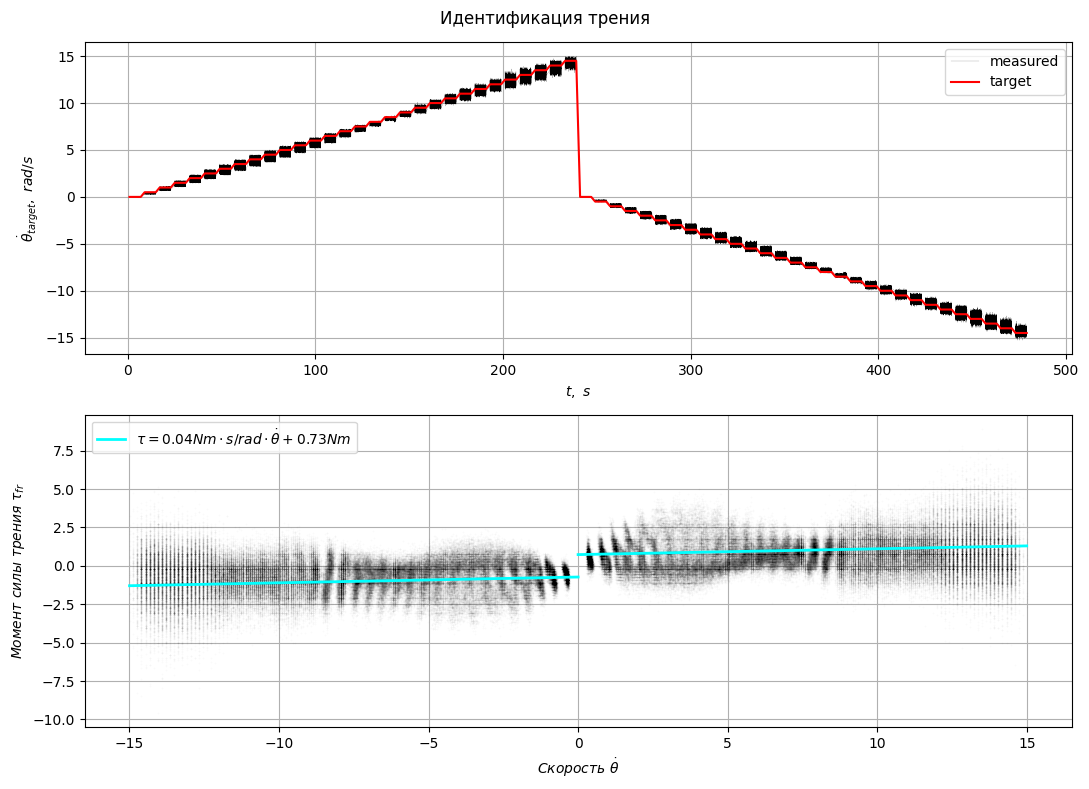

damping: 0.03779301045257156
frictionloss: 0.72999493536025


In [7]:
from scipy.signal import medfilt, savgol_filter

data = load("damping.npz")

T = data["T"]

mod = np.fmod(T, 8)
iloc = np.where((mod > 1) * (mod < 7))

V_raw = data["V_raw"][iloc]
I_raw = data["I_raw"][iloc]
V_target = data["V_target"][iloc]

T = T[iloc]

V = V_raw
I = I_raw

iloc = np.where((np.abs(V) > 0.2) * (np.abs(V) < 15))
V = V[iloc]
I = I[iloc]

itop = np.where(V > 0)
ibot = np.where(V < 0)

topavg = np.average(I[itop])
botavg = np.average(I[ibot])

# Tune zero
I -= (topavg + botavg) / 2

Tq = I * KT_REAL

p, cov = np.polyfit(np.abs(V), np.abs(Tq), 1, cov=True)
p_inv = (p[0], -p[1])
print(np.sqrt(cov))
x = np.array([0, np.max(np.abs(V))])
x_inv = np.array([-np.max(np.abs(V)), 0])

fig, ax = plt.subplots(2, 1)
fig.set_size_inches(11, 8)

ax[0].plot(T, V_raw, 'k-', lw=.1, label="measured")
ax[0].plot(T, V_target, "r-", label='target')
ax[0].grid()
ax[0].set_ylabel("$\\dot{\\theta}_{target}, ~rad/s$")
ax[0].set_xlabel("$t, ~s$")
ax[0].legend()

# Среднее по экспериментам в mjx_sysid
p_mjx = [0.058, 0.49]
p_mjx_inv = [p_mjx[0], -p_mjx[1]]

thetad = "\\dot{\\theta}"

ax[1].plot(V, Tq, 'ko', ms=.5, alpha=.015)
ax[1].plot(x, np.polyval(p, x), '-', c="cyan", label=f"$\\tau = {round(p[0], 2)}Nm\\cdot s / rad \\cdot {thetad} + {round(p[1], 2)}Nm$", lw=2)
ax[1].plot(x_inv, np.polyval(p_inv, x_inv), '-', c="cyan", lw=2)
#ax[1].plot(x, np.polyval(p_mjx, x), '-', c="magenta", label="mjx_sysid (avg)", lw=2)
#ax[1].plot(x_inv, np.polyval(p_mjx_inv, x_inv), '-', c="magenta", lw=2)
#ax[1].set_title("Экспериментальная характеристика трения")
ax[1].set_ylabel("$Момент~ силы~ трения ~\\tau_{fr}$")
ax[1].set_xlabel("$Скорость~ \\dot{\\theta}$")
ax[1].grid()
ax[1].legend()


fig.suptitle("Идентификация трения")
fig.tight_layout()
plt.show()

DAMPING = p[0]
FRICTIONLOSS = p[1]

data = {"torque": Tq, "vel": V}
save("friction_result", **data)

print(f"damping: {p[0]}\nfrictionloss: {p[1]}")

## Идентификация armature

1. Подаем управляющий сигнал момента в виде импульса амплитуды $\tau_{0,~target}$
2. Вычисляем ускорение на участке разгона ($\ddot{\theta}_{up}$) и торможения ($\ddot{\theta}_{down}$)
3. Вычисляем момент инерции по формуле

$$J = \frac{\tau_{0,~meas}}{\ddot{\theta}_{up} - \ddot{\theta}_{down}}$$

In [8]:
PULSE_LEN_S = 2
AMPLITUDE = 3 # \tau_0 target

pulse_len = int(1e3 * PULSE_LEN_S / SIGNAL_DT_MS)

Tq_target = np.zeros((3*pulse_len), dtype=np.float64)
Tq_target[pulse_len:-pulse_len] = AMPLITUDE

T = np.arange(0, 3 * pulse_len) * 1e-3 * SIGNAL_DT_MS

In [ ]:
brake = None
gen = None
gen = encosid.SignalGenerator("can0", 3)

gen.set_mode(2) # torque
X_raw, V_raw, I_raw = map(np.array, gen.play_signal(Tq_target, SIGNAL_DT_MS))

data = {"X_raw": X_raw, "V_raw": V_raw, "I_raw": I_raw, "Tq_target": Tq_target, "T": T}
save("armature", **data)

<>:65: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:66: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:67: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:65: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:66: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:67: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\tndrd\AppData\Local\Temp\ipykernel_13652\2518968305.py:65: SyntaxWa

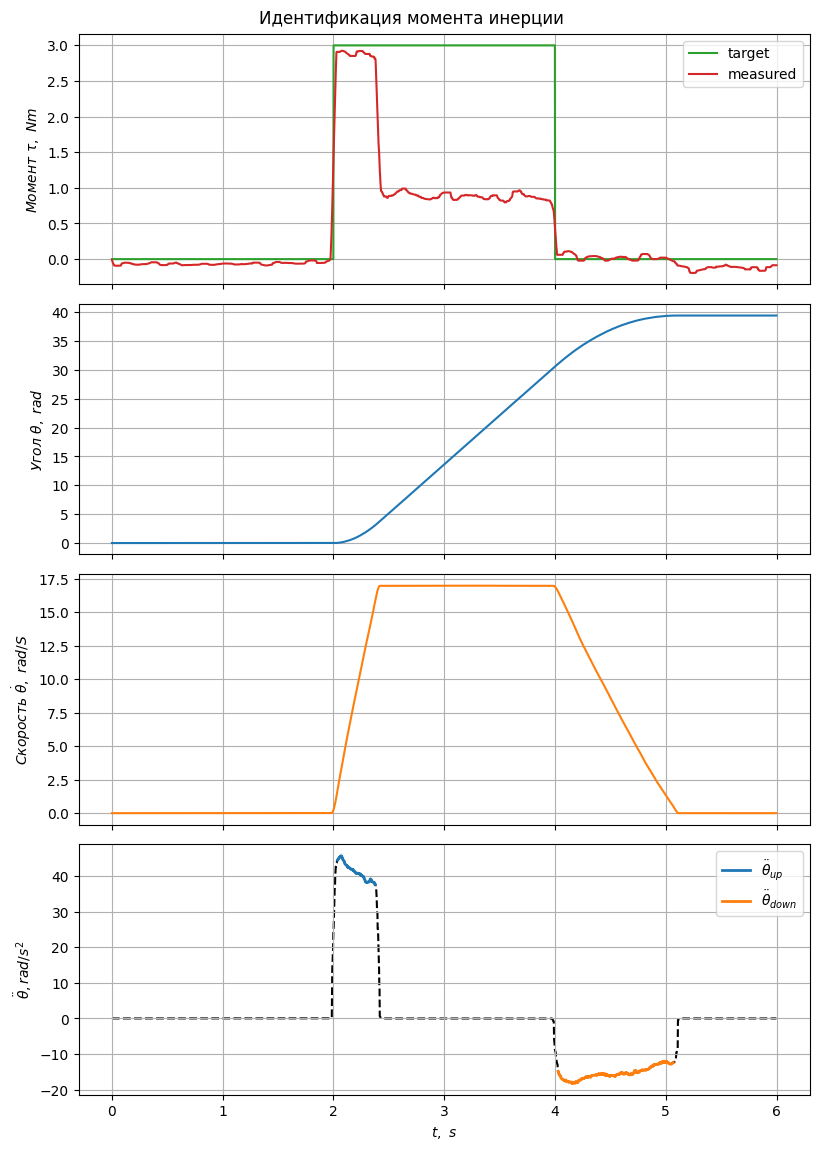

armature (target torque) ~ 0.050964014456315355
armature (measured torque) ~ 0.05299697337110995


In [9]:
data = load("armature.npz")

T = data["T"]
X_raw = data["X_raw"]
V_raw = data["V_raw"]
I_raw = data["I_raw"]
Tq_target = data["Tq_target"]

def stitch(Y, gap=2*np.pi, tol=1e-2):
  Y = Y.copy()
  for i in range(len(Y) - 1):
    dy = Y[i + 1] - Y[i]
    shift = dy # TODO include remainder
    if np.abs(dy) >= gap - tol:
      Y[i + 1:] -= shift
  return Y


X = stitch(X_raw - X_raw[0])
V = medfilt(savgol_filter(V_raw, 100, 3), 101)
I = medfilt(savgol_filter(I_raw, 100, 3), 101)
#I = I_raw
#V = V_raw

Tq = I * KT_REAL


Ac = np.zeros_like(T)
Ac[1:-1] = (V[2:] - V[:-2]) * 5e2 / SIGNAL_DT_MS
Ac = medfilt(Ac, 101)



itop = np.where(Ac > 0.2)
ibot = np.where(Ac < -0.2)


def stripidx(idx, eps):
  tmin = T[np.min(idx)]
  tmax = T[np.max(idx)]

  iwind = np.where((tmin + eps < T[idx]) * (T[idx] < tmax - eps))
  return idx[iwind]

itop = stripidx(itop[0], 0.05) 
ibot = stripidx(ibot[0], 0.05) 

fig, ax = plt.subplots(4, 1, sharex=True)
fig.set_size_inches(8.27, 11.69)

cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

ax[1].plot(T, X, label="position", c=cycle[0])
ax[2].plot(T, V, label="speed", c=cycle[1])
ax[0].plot(T, Tq_target, label="target", c=cycle[2])
ax[0].plot(T, Tq, label="measured", c=cycle[3])

ax[1].set_ylabel("$Угол ~\\theta, ~rad$")
ax[2].set_ylabel("$Скорость ~\\dot{\\theta}, ~rad/S$")
ax[0].set_ylabel("$Момент~\\tau, ~Nm$")

ax[0].legend()

ax[3].plot(T, Ac, 'k--', zorder=0)
ax[3].plot(T[itop], Ac[itop], lw=2, label="$\ddot{\\theta}_{up}$")
ax[3].plot(T[ibot], Ac[ibot], lw=2, label="$\ddot{\\theta}_{down}$")
ax[3].set_ylabel("$\ddot{\\theta}, rad/s^2$")
ax[3].set_xlabel("$t, ~s$")
ax[3].legend()
#ax[3].set_title("Acceleration")


for axs in ax:
  axs.grid()

plt.suptitle("Идентификация момента инерции")
fig.tight_layout()
plt.show()


acc = (np.average(Ac[itop]) - np.average(Ac[ibot])) # rad / s^2

ARMATURE_1 = (AMPLITUDE / acc)
ARMATURE = ((np.mean(Tq[itop])) / acc)

print(f"armature (target torque) ~ {ARMATURE}")
print(f"armature (measured torque) ~ {ARMATURE_1}")

# Итог

In [10]:
print(f'armature="{round(ARMATURE, 4)}" frictionloss="{round(FRICTIONLOSS, 4)}" damping="{round(DAMPING, 4)}"')

armature="0.051" frictionloss="0.73" damping="0.0378"
